In [1]:
import time
import matplotlib.pyplot as plt
import cantera as ct

gas = ct.Solution("gri30.yaml")

# 2. Define reactor conditions
reactor_temperature = 925  # Kelvin (Keeping the original high temperature for isothermal reaction)
reactor_pressure = 1.046138 * ct.one_atm  # in atm (approx 1.06 bars)

# Stoichiometric CH4 + 2(O2 + 3.76 N2) -> CO2 + 2H2O + 7.52 N2
# For phi = 0.5: CH4 + (2/0.5)(O2 + 3.76 N2) = CH4 + 4(O2 + 3.76 N2) = CH4 + 4 O2 + 15.04 N2
# Total moles = 1 + 4 + 15.04 = 20.04
inlet_concentrations = {"CH4": 0.0499, "O2": 0.1996, "N2": 0.7505}
gas.TPX = reactor_temperature, reactor_pressure, inlet_concentrations

residence_time = 2  # s 
reactor_volume = 30.5 * (1e-2) ** 3  # m3

# Simulation termination criterion
max_simulation_time = 50  # seconds 

# Create reservoirs for the inlet and exhaust
fuel_air_mixture_tank = ct.Reservoir(gas)
exhaust = ct.Reservoir(gas)

# Create the stirred reactor
# energy="off" means the reactor is isothermal (temperature is fixed)
stirred_reactor = ct.IdealGasMoleReactor(gas, energy="off", volume=reactor_volume)

# Create a mass flow controller to control the inlet flow rate
mass_flow_controller = ct.MassFlowController(
    upstream=fuel_air_mixture_tank,
    downstream=stirred_reactor,
    mdot=stirred_reactor.mass / residence_time,
)

# Create a pressure regulator to maintain constant pressure in the reactor
pressure_regulator = ct.PressureController(
    upstream=stirred_reactor,
    downstream=exhaust,
    primary=mass_flow_controller,
    K=1e-3, # Proportional gain 
)



In [2]:
# Create a reactor network 
reactor_network = ct.ReactorNet([stirred_reactor])

# Create a SolutionArray to store the data over time
time_history = ct.SolutionArray(gas, extra=["t"])

# Start the stopwatch
tic = time.time()

# Set simulation start time to zero
t = 0
counter = 0 # Initialize step counter
while t < max_simulation_time:
    t = reactor_network.step()

    # Store data periodically (e.g., every 10 steps) to reduce memory usage
    if counter % 10 == 0:
        # Extract the state of the reactor
        time_history.append(stirred_reactor.thermo.state, t=t)

    counter += 1

# Stop the stopwatch
toc = time.time()

print(f"Simulation Took {toc-tic:3.2f}s to compute, with {counter} steps.")




Simulation Took 0.04s to compute, with 408 steps.


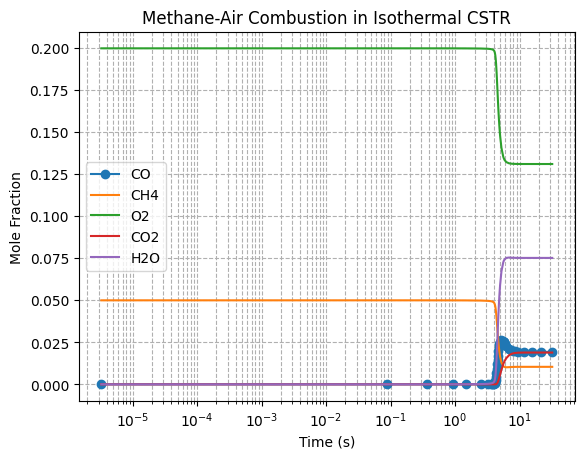

In [3]:
plt.figure()
plt.semilogx(time_history.t, time_history("CO").X, "-o", label="CO")
plt.semilogx(time_history.t, time_history("CH4").X, "-", label="CH4")
plt.semilogx(time_history.t, time_history("O2").X, "-", label="O2")
plt.semilogx(time_history.t, time_history("CO2").X, "-", label="CO2")
plt.semilogx(time_history.t, time_history("H2O").X, "-", label="H2O")


plt.xlabel("Time (s)")
plt.ylabel("Mole Fraction")
plt.title("Methane-Air Combustion in Isothermal CSTR")
plt.legend()
plt.grid(True, which="both", linestyle="--")
plt.show()